# Step 4 — 1D Burgers' Equation

*13 Steps to Navier-Stokes with somax (inspired by Lorena Barba's CFD Python)*

Steps 1--3 introduced convection and diffusion separately. Now we bring them together in **Burgers' equation** — the simplest PDE that exhibits the competition between nonlinear steepening and viscous smoothing. This balance is at the heart of turbulence and is the reason Burgers' equation has been called "the hydrogen atom of fluid dynamics."

**What you'll learn:**

1. How convection and diffusion compete to shape the solution
2. How viscosity controls the balance (low $\nu$: shocks; high $\nu$: smooth decay)
3. How to compare solutions at different viscosities side by side
4. How to compute $\partial \mathcal{L} / \partial \nu$ for parameter estimation

## The PDE

$$
\frac{\partial u}{\partial t} + u \frac{\partial u}{\partial x}
= \nu \frac{\partial^2 u}{\partial x^2}
$$

The left-hand side is the nonlinear convection from Step 2 (inviscid Burgers). The right-hand side is the diffusion from Step 3. The dimensionless ratio that controls the balance is the **Reynolds number**:

$$
\mathrm{Re} = \frac{U L}{\nu}
$$

where $U$ is a characteristic velocity and $L$ a characteristic length. At high Re the nonlinear term dominates (sharp gradients, near-shocks). At low Re diffusion dominates (smooth, decaying profiles).

## Grid layout and boundary conditions

somax uses the **Arakawa C-grid** from finitevolX. In 1D, scalar fields (like $u$) live at **T-points** (cell centres) and fluxes are computed at **U-points** (cell edges):

```
 ghost                    interior                     ghost
 ┌─────┬──────┬──────┬──────┬──────┬──────┬──────┬─────┐
 │  G  │  T₁  │  T₂  │  T₃  │ ···  │ Tₙ₋₁│  Tₙ  │  G  │
 └──┬──┴──┬───┴──┬───┴──┬───┴──┬───┴──┬───┴──┬───┴──┬──┘
    U₀    U₁     U₂     U₃           Uₙ₋₁    Uₙ    Uₙ₊₁
         ←── dx ──→
```

- **T-points** (indices `1:-1`): where `u` is stored and updated
- **U-points**: where upwind flux reconstruction computes the advection term $\partial(u^2/2)/\partial x$
- **Ghost cells** (indices `0` and `-1`): filled by BCs before each RHS evaluation

Burgers' equation combines both **advection** (upwind reconstruction at U-points) and **diffusion** (Laplacian stencil at T-points). The Laplacian $\,(u_{i+1} - 2u_i + u_{i-1})/\Delta x^2\,$ reaches both neighbours, so ghost cells are essential for both terms.

**Periodic BCs** copy the last interior value into the opposite ghost cell:

```
 u[0] = u[-2]      (left ghost ← rightmost interior)
 u[-1] = u[1]      (right ghost ← leftmost interior)
```

This makes the domain wrap around so that both advection and diffusion operate seamlessly across the boundary.

In [1]:
from __future__ import annotations

import diffrax as dfx
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from somax.models import Burgers1D, Burgers1DState

## 1. Create the model

`Burgers1D` combines upwind advection with centered diffusion. The viscosity $\nu$ is a differentiable parameter.

In [2]:
nx, Lx, nu = 200, 4.0, 0.05
model = Burgers1D.create(nx=nx, Lx=Lx, nu=nu)

print(f"Grid: Nx={model.grid.Nx}, dx={model.grid.dx:.4f}")
print(f"Viscosity nu = {float(model.params.nu)}")
print(f"Advection method: {model.method}")

Grid: Nx=202, dx=0.0200
Viscosity nu = 0.05000000074505806
Advection method: upwind1


## 2. Initial condition

A Gaussian bump centered at $x = 1.5$. The positive amplitude means the nonlinear term will try to steepen the right flank while diffusion resists.

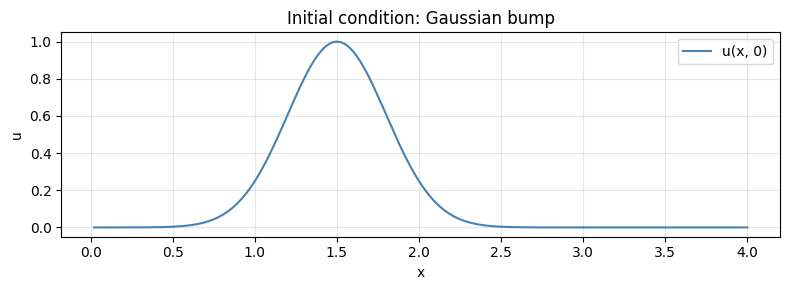

In [3]:
x = jnp.arange(model.grid.Nx) * model.grid.dx

mu0, sigma0 = 1.5, 0.3
u0 = jnp.exp(-0.5 * ((x - mu0) / sigma0) ** 2)

state0 = Burgers1DState(u=u0)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(x[1:-1], u0[1:-1], color="steelblue", lw=1.5, label="u(x, 0)")
ax.set_xlabel("x")
ax.set_ylabel("u")
ax.set_title("Initial condition: Gaussian bump")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Forward simulation — the Burgers dynamics

The initial steepening (convection) is gradually balanced by diffusion, producing a characteristic asymmetric profile.

In [4]:
t0, t1, dt = 0.0, 0.8, 0.001
ts = jnp.array([0.0, 0.05, 0.1, 0.2, 0.4, 0.8])

sol = model.integrate(
    state0,
    t0=t0,
    t1=t1,
    dt=dt,
    saveat=dfx.SaveAt(ts=ts),
)

print(f"Trajectory shape: u={sol.ys.u.shape}")

Trajectory shape: u=(6, 202)


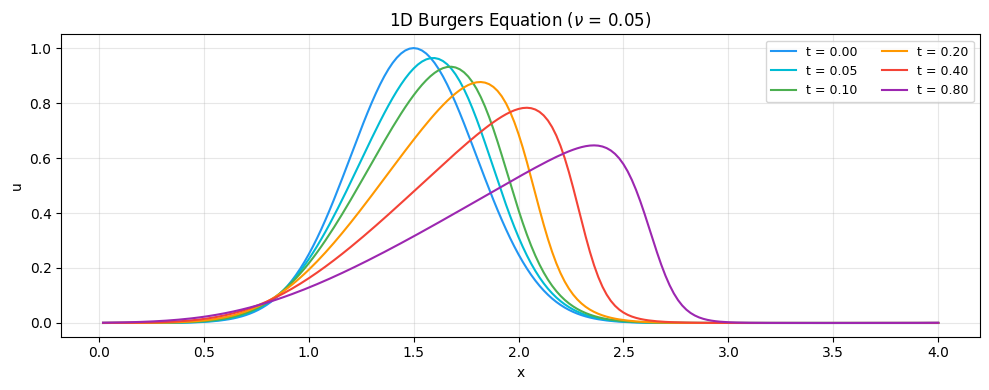

In [5]:
colors_snap = ["#2196F3", "#00BCD4", "#4CAF50", "#FF9800", "#F44336", "#9C27B0"]

fig, ax = plt.subplots(figsize=(10, 4))
for i, t_snap in enumerate(ts):
    ax.plot(
        x[1:-1],
        sol.ys.u[i, 1:-1],
        color=colors_snap[i],
        lw=1.5,
        label=f"t = {float(t_snap):.2f}",
    )
ax.set_xlabel("x")
ax.set_ylabel("u")
ax.set_title(f"1D Burgers Equation ($\\nu$ = {nu})")
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Notice the initial rightward steepening (Steps 1--2) followed by overall decay (Step 3). The profile develops the classic Burgers asymmetry: a steep front on the right and a gentle tail on the left.

## 4. Low vs. high viscosity comparison

The viscosity $\nu$ controls the balance between steepening and smoothing. We compare three values to see the effect.

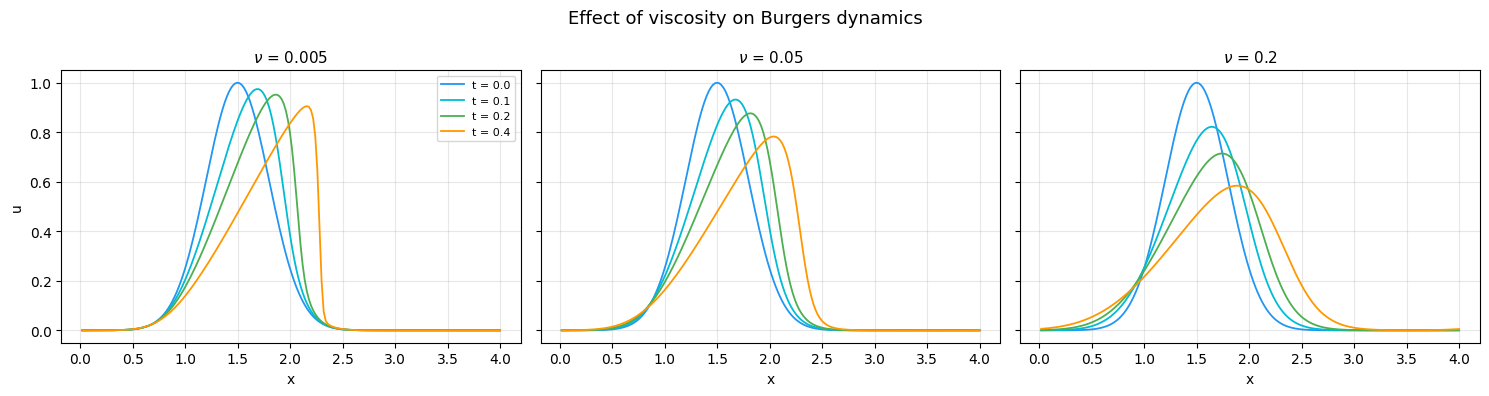

In [6]:
nu_values = [0.005, 0.05, 0.2]
colors_nu = ["#F44336", "#4CAF50", "#2196F3"]
labels_nu = [f"$\\nu$ = {v}" for v in nu_values]

t_compare = 0.4

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for j, nu_val in enumerate(nu_values):
    m = Burgers1D.create(nx=nx, Lx=Lx, nu=nu_val)
    ts_compare = jnp.array([0.0, 0.1, 0.2, 0.4])
    sol_j = m.integrate(
        state0,
        t0=0.0,
        t1=0.4,
        dt=0.001,
        saveat=dfx.SaveAt(ts=ts_compare),
    )
    ax = axes[j]
    for k, t_snap in enumerate(ts_compare):
        ax.plot(
            x[1:-1],
            sol_j.ys.u[k, 1:-1],
            color=colors_snap[k],
            lw=1.3,
            label=f"t = {float(t_snap):.1f}",
        )
    ax.set_xlabel("x")
    ax.set_title(labels_nu[j], fontsize=11)
    ax.grid(True, alpha=0.3)
    if j == 0:
        ax.set_ylabel("u")
        ax.legend(fontsize=8)

fig.suptitle("Effect of viscosity on Burgers dynamics", fontsize=13)
plt.tight_layout()
plt.show()

**Low viscosity** ($\nu = 0.005$): the nonlinear term dominates, producing a sharp front that resembles a shock.

**Medium viscosity** ($\nu = 0.05$): steepening and diffusion are balanced — the classic Burgers profile.

**High viscosity** ($\nu = 0.2$): diffusion dominates, and the profile decays almost symmetrically (nearly pure diffusion).

## 5. Side-by-side at a fixed time

Overlaying the three viscosities at $t = 0.4$ makes the contrast even clearer.

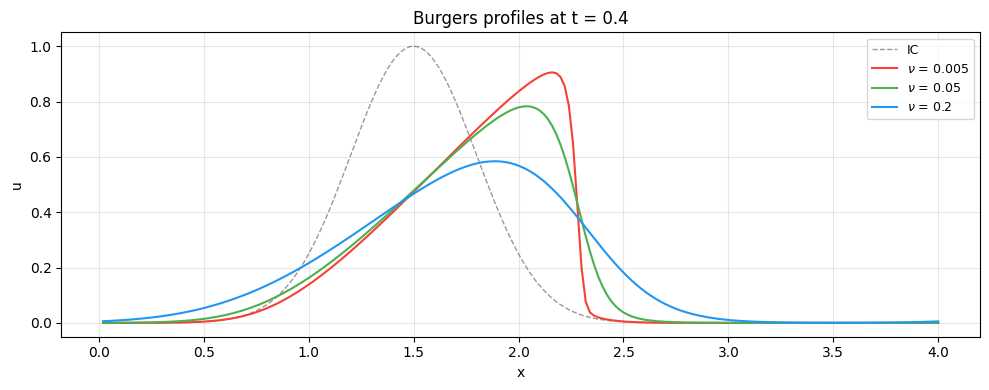

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x[1:-1], u0[1:-1], "k--", lw=1.0, alpha=0.4, label="IC")

for j, nu_val in enumerate(nu_values):
    m = Burgers1D.create(nx=nx, Lx=Lx, nu=nu_val)
    sol_j = m.integrate(
        state0,
        t0=0.0,
        t1=t_compare,
        dt=0.001,
        saveat=dfx.SaveAt(t1=True),
    )
    ax.plot(
        x[1:-1],
        sol_j.ys.u[0, 1:-1],
        color=colors_nu[j],
        lw=1.5,
        label=labels_nu[j],
    )

ax.set_xlabel("x")
ax.set_ylabel("u")
ax.set_title(f"Burgers profiles at t = {t_compare}")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Energy evolution

Energy $E = \frac{1}{2} \int u^2 \, dx$ always decays for Burgers (the diffusion term dissipates it). Higher viscosity means faster decay.

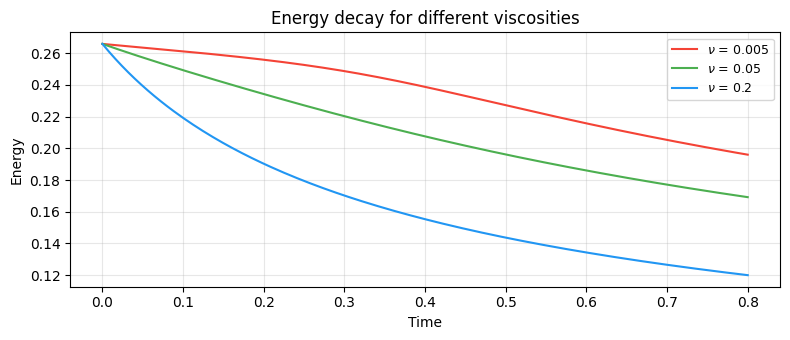

In [8]:
ts_dense = jnp.linspace(t0, t1, 200)

fig, ax = plt.subplots(figsize=(8, 3.5))

for j, nu_val in enumerate(nu_values):
    m = Burgers1D.create(nx=nx, Lx=Lx, nu=nu_val)
    sol_j = m.integrate(
        state0,
        t0=t0,
        t1=t1,
        dt=0.001,
        saveat=dfx.SaveAt(ts=ts_dense),
    )
    energy_j = jax.vmap(m.diagnose)(sol_j.ys).energy
    ax.plot(ts_dense, energy_j, color=colors_nu[j], lw=1.5, label=labels_nu[j])

ax.set_xlabel("Time")
ax.set_ylabel("Energy")
ax.set_title("Energy decay for different viscosities")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Differentiability demo — gradient w.r.t. viscosity

Suppose we observe a diffusing, steepening profile and want to infer the viscosity. We compute $\partial \mathcal{L} / \partial \nu$ where $\mathcal{L}$ measures the mismatch between the predicted and observed final profile.

In [9]:
# Generate a "target" observation using nu = 0.08
model_true = Burgers1D.create(nx=nx, Lx=Lx, nu=0.08)
sol_true = model_true.integrate(
    state0, t0=0.0, t1=0.4, dt=0.001, saveat=dfx.SaveAt(t1=True)
)
u_obs = sol_true.ys.u[0]


@eqx.filter_grad
def grad_wrt_model(m):
    """Gradient of MSE loss w.r.t. viscosity."""
    sol = m.integrate(state0, t0=0.0, t1=0.4, dt=0.001)
    u_pred = sol.ys.u[-1]
    return jnp.mean((u_pred[1:-1] - u_obs[1:-1]) ** 2)


# Evaluate gradient at our initial guess (nu = 0.05)
grads = grad_wrt_model(model)

print("--- Gradient w.r.t. model parameters ---")
print(f"  Current nu = {float(model.params.nu):.3f}")
print("  True nu    = 0.08")
print(f"  dL/d(nu)   = {float(grads.params.nu):.6f}")
print()
print("A negative gradient means increasing nu (toward the true value)")
print("would decrease the loss — the gradient points in the right direction.")

--- Gradient w.r.t. model parameters ---
  Current nu = 0.050
  True nu    = 0.08
  dL/d(nu)   = -0.041828

A negative gradient means increasing nu (toward the true value)
would decrease the loss — the gradient points in the right direction.


### Gradient landscape

We can sweep over $\nu$ values to see the full loss landscape and verify that the gradient direction is consistent.

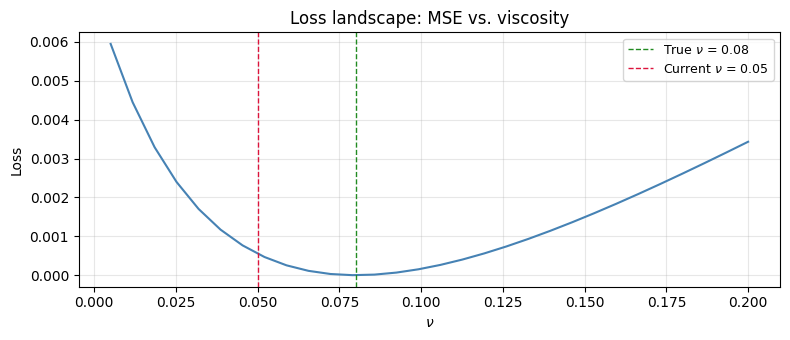

In [10]:
nu_sweep = jnp.linspace(0.005, 0.2, 30)


def loss_for_nu(nu_val):
    m = Burgers1D.create(nx=nx, Lx=Lx, nu=float(nu_val))
    sol = m.integrate(state0, t0=0.0, t1=0.4, dt=0.001)
    u_pred = sol.ys.u[-1]
    return jnp.mean((u_pred[1:-1] - u_obs[1:-1]) ** 2)


losses = jnp.array([loss_for_nu(v) for v in nu_sweep])

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(nu_sweep, losses, color="steelblue", lw=1.5)
ax.axvline(0.08, color="forestgreen", ls="--", lw=1.0, label="True $\\nu$ = 0.08")
ax.axvline(
    float(model.params.nu),
    color="crimson",
    ls="--",
    lw=1.0,
    label="Current $\\nu$ = 0.05",
)
ax.set_xlabel("$\\nu$")
ax.set_ylabel("Loss")
ax.set_title("Loss landscape: MSE vs. viscosity")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary of 1D models

| Step | PDE | Key physics | somax model |
|------|-----|-------------|-------------|
| 1 | $u_t + c u_x = 0$ | Translation at constant speed | `LinearConvection1D` |
| 2 | $u_t + u u_x = 0$ | Self-steepening, shocks | `NonlinearConvection1D` |
| 3 | $u_t = \nu u_{xx}$ | Smoothing, energy decay | `Diffusion1D` |
| 4 | $u_t + u u_x = \nu u_{xx}$ | Steepening vs. smoothing | `Burgers1D` |

All four models share the same API contract:

- `Model.create(...)` — factory with physical parameters
- `model.integrate(state0, t0, t1, dt, saveat=...)` — forward sim
- `model.diagnose(state)` — on-demand diagnostics
- `eqx.filter_grad(loss)(model)` — differentiable w.r.t. parameters

**What comes next:** These 1D building blocks extend naturally to 2D. Steps 5--8 will introduce 2D convection, diffusion, and the cavity flow problem, building toward the full Navier-Stokes equations.